In [1]:
import pandas as pd
import numpy as np
import pm4py as pm4

In [2]:
dataframe = pd.read_csv('/home/abraao/Downloads/running-example.csv', sep=';')
print(dataframe.columns.tolist())
dataframe.head()

['case_id', 'activity', 'timestamp', 'costs', 'resource']


,case_id,activity,timestamp,costs,resource
0,3,register request,2010-12-30 14:32:00+01:00,50,Pete
1,3,examine casually,2010-12-30 15:06:00+01:00,400,Mike
2,3,check ticket,2010-12-30 16:34:00+01:00,100,Ellen
3,3,decide,2011-01-06 09:18:00+01:00,200,Sara
4,3,reinitiate request,2011-01-06 12:18:00+01:00,200,Sara


In [3]:
dataframe = dataframe.rename(columns={'case_id': 'case:case_id'})

dataframe = pm4.format_dataframe(
    dataframe,
    case_id='case:case_id',
    activity_key='activity',
    timestamp_key='timestamp'
)

In [4]:
event_log = pm4.convert_to_event_log(dataframe)

print(event_log)

[{'attributes': {'case_id': 1, 'concept:name': '1'}, 'events': [{'activity': 'register request', 'timestamp': Timestamp('2010-12-30 10:02:00+0000', tz='UTC'), 'costs': 50, 'resource': 'Pete', 'concept:name': 'register request', 'time:timestamp': Timestamp('2010-12-30 10:02:00+0000', tz='UTC'), '@@index': 0, '@@case_index': 0}, '..', {'activity': 'reject request', 'timestamp': Timestamp('2011-01-07 13:24:00+0000', tz='UTC'), 'costs': 200, 'resource': 'Pete', 'concept:name': 'reject request', 'time:timestamp': Timestamp('2011-01-07 13:24:00+0000', tz='UTC'), '@@index': 4, '@@case_index': 0}]}, '....', {'attributes': {'case_id': 6, 'concept:name': '6'}, 'events': [{'activity': 'register request', 'timestamp': Timestamp('2011-01-06 14:02:00+0000', tz='UTC'), 'costs': 50, 'resource': 'Mike', 'concept:name': 'register request', 'time:timestamp': Timestamp('2011-01-06 14:02:00+0000', tz='UTC'), '@@index': 37, '@@case_index': 5}, '..', {'activity': 'pay compensation', 'timestamp': Timestamp('2

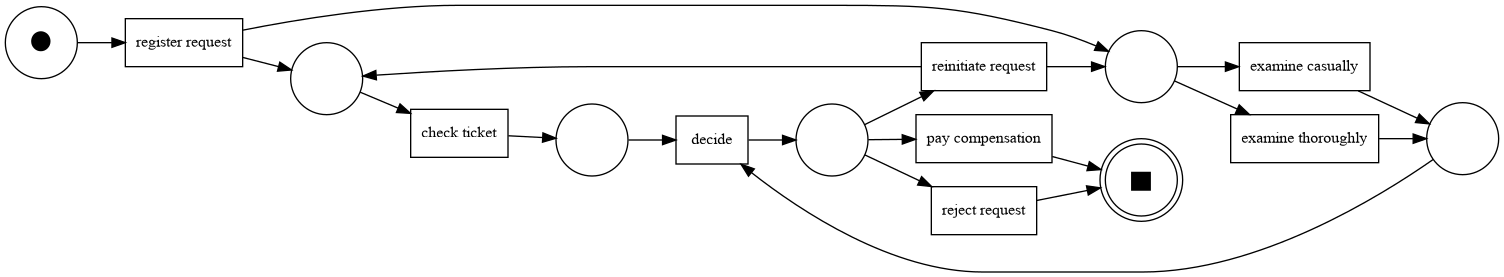

In [11]:
net, im, fm  = pm4.discover_petri_net_alpha(event_log)

pm4.view_petri_net(net, im, fm)